*0321(금) 3주차 과제*\
*핸즈온 9장 비지도 학습 p.328-347*

# 9.2 가우시안 모델

**가우시안 혼합 모델(GMM)**
- 샘플이 파라미터가 알려지지 않은 여러 개의 혼합된 가우시안 분포에서 생성되었다고 가정하는 확률 모델
- 하나의 가우시안 분포에서 생성된 모든 샘플은 하나의 클러스터를 형성함 (보통 타원형 클러스터)

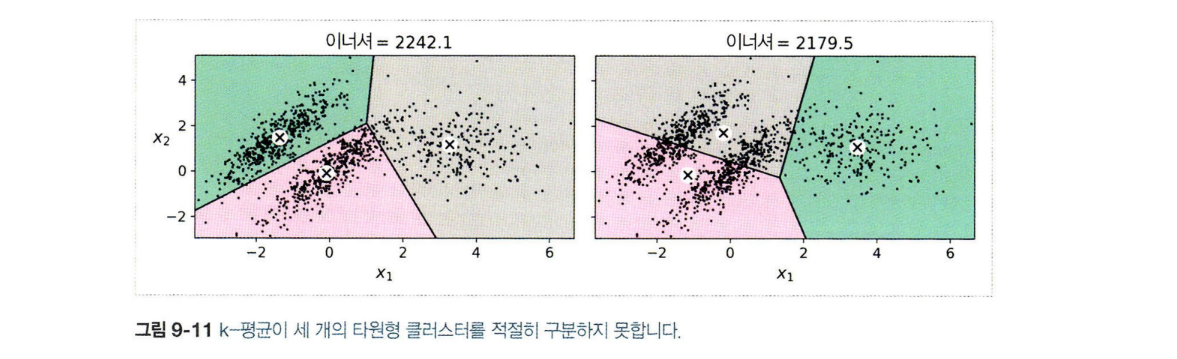

    각 클러스터는 위 그림처럼 타원의 모양, 크기, 밀집도, 방향이 다름

**GMM 변종 중 간단한 버전 구현**
- 사전에 가우시안 분포의 개수 k를 알아야 함
- 데이터셋 X가 다음 과정으로 생성되었다고 가정

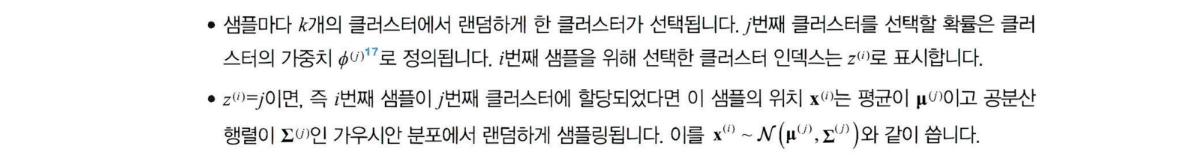

> **확률 변수 사이의 조건부 의존성**

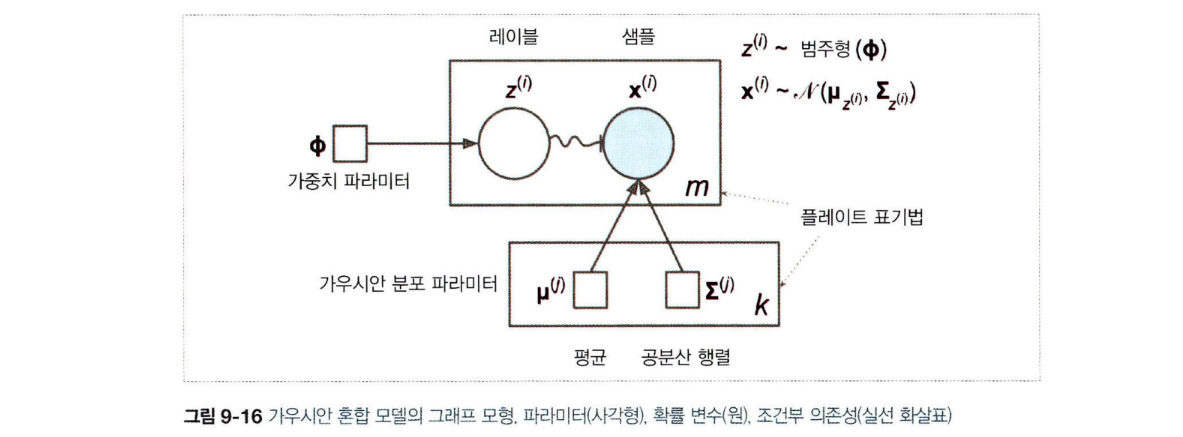

그림을 보는 방법

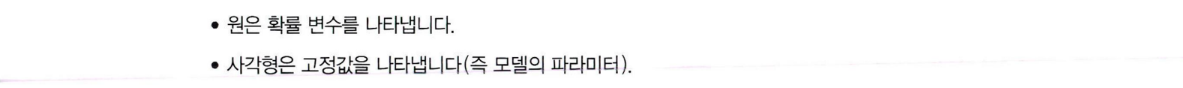

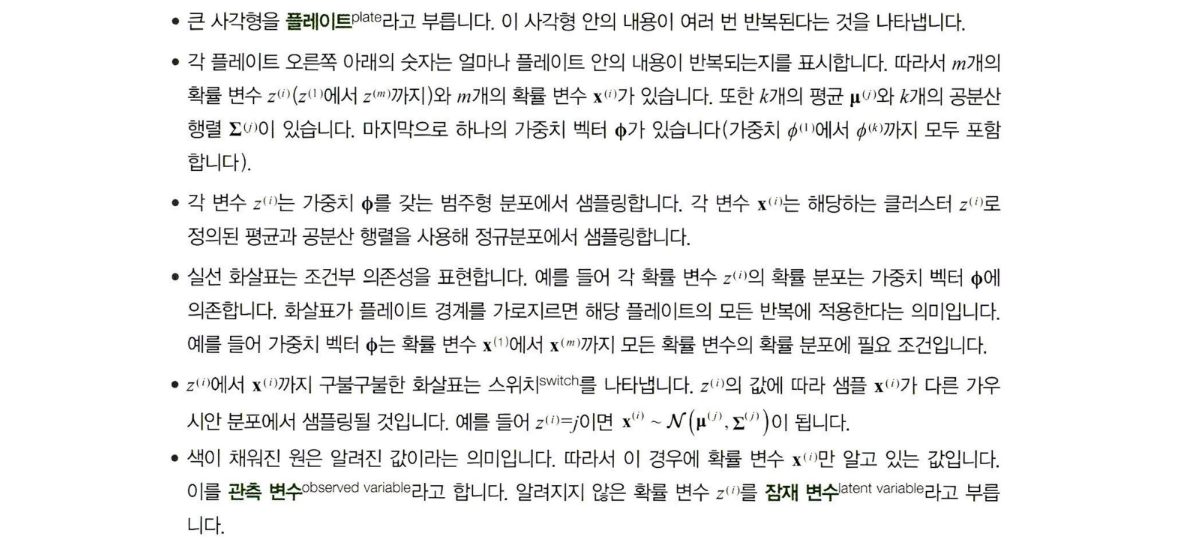

In [18]:
# 데이터 불러오기

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise= 0.05)

In [19]:
# 가중치, 평균, 공분산 구하기

from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10)

In [20]:
# 가중치 확인

gm.weights_

array([0.57633503, 0.21412576, 0.20953922])

In [21]:
# 평균 확인

gm.means_

array([[ 0.49222854,  0.25115196],
       [ 1.71814166, -0.07121907],
       [-0.7290844 ,  0.57005627]])

In [22]:
# 공분산 확인

gm.covariances_

array([[[ 0.15931484, -0.09284983],
        [-0.09284983,  0.2839069 ]],

       [[ 0.06377405,  0.06717258],
        [ 0.06717258,  0.08867912]],

       [[ 0.06255085,  0.06761401],
        [ 0.06761401,  0.08892881]]])

- 실제 데이터를 생성하기 위해 사용한 가중치는 0.2 / 0.2 / 0/6
- 평균, 분산 행렬도 이 알고리즘이 찾은 것과 비슷

**기댓값-최대화(EM)**
- 클러스터 파라미터를 랜덤하게 초기화하고 수렴할 때까지 두 단계를 반복함
 1. 기댓값 단계: 샘플을 클러스터에 할당함
 2. 최대화 단계: 클러스터를 업데이트함

- 군집 입장에서 보면, EM은 클러스터의 중심/크기/모양/방향/상대적 가중치를 찾는 k-평균의 일반화
- k-평균과 달리 하드 클러스터 할당이 아닌 **소프트 클러스터 할당**을 사용

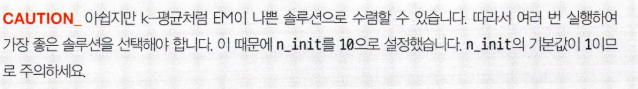

In [23]:
# 알고리즘 수렴 여부 확인

gm.converged_

True

In [24]:
# 반복 횟수 확인

gm.n_iter_

17

- 각 클러스터의 위치,크기, 모양, 방향, 가중치 예측 완료
- 이제 예측 가능!
 - 하드 군집: 새로운 샘플을 가장 비슷한 클러스터에 손쉽게 할당 가능 -> predict()
 - 소프트 군집: 특정 클러스터에 속할 확률을 예측 가능 -> predict_proba()

In [25]:
# 하드 군집 -> predict() 메서드

gm.predict(X)

array([2, 2, 0, 0, 2, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 1, 0, 2, 0, 2, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 2, 0, 0, 0, 2, 0,
       0, 0, 0, 1, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 2, 0, 2,
       0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 1,
       2, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 1, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 0, 1, 0, 2, 1, 0, 2,
       0, 2, 2, 0, 0, 2, 2, 0, 1, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0,
       2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0,
       1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 2, 0,
       0, 1, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 1, 0, 0,

In [26]:
# 소프트 군집 -> predict_proba() 메서드

gm.predict_proba(X)

array([[1.52617690e-003, 6.33129928e-127, 9.98473823e-001],
       [8.92337525e-004, 4.30627698e-160, 9.99107662e-001],
       [1.00000000e+000, 1.06858165e-013, 1.38056063e-081],
       ...,
       [1.90952055e-004, 1.51706476e-136, 9.99809048e-001],
       [7.08973714e-005, 4.91671000e-147, 9.99929103e-001],
       [1.00000000e+000, 1.55167786e-077, 1.80606309e-013]])

In [27]:
# 모델에서 새로운 샘플을 만들 수 있음

X_new, y_new = gm.sample(6)

In [28]:
X_new

array([[ 0.25370901,  0.55856893],
       [-0.32160746,  0.16103295],
       [ 0.86070245,  0.1033407 ],
       [ 1.6962717 , -0.43388601],
       [-0.91186352,  0.26393797],
       [-0.98537238,  0.25638074]])

In [29]:
y_new

array([0, 0, 0, 1, 2, 2])

In [30]:
# 주어진 위치에서 모델의 밀도 추정 -> score_sample() 메서드
# 점수가 높을수록 밀도 높음

gm.score_samples(X)

array([-2.93558822e+00, -8.47995844e-01, -1.42646385e+00, -1.32495174e+00,
       -1.45718027e+00, -1.59468329e+00, -1.82632138e+00, -1.52937708e+00,
       -1.46701088e+00, -5.09928137e-01, -1.51889043e+00, -4.46484170e-01,
       -1.80375410e+00, -1.78116670e+00, -1.79067558e+00, -4.31119639e-01,
       -1.52090458e+00, -1.32393989e-01, -1.40831795e+00, -1.57059713e+00,
       -1.00682023e+00, -1.54449971e+00, -1.85411966e+00, -4.46661543e-01,
       -1.15488339e+00, -1.75703927e+00, -1.62280130e+00, -1.84697059e+00,
       -1.51032301e+00, -6.14490978e-01, -1.56017303e+00, -9.12125514e-01,
       -1.51475121e-01, -2.14998912e+00, -1.57668485e+00, -1.88844928e-01,
       -2.12203195e+00, -1.35919495e+00, -1.53571922e+00, -2.97101597e-02,
       -1.43637955e+00, -2.43909834e-01, -2.27210440e-01, -1.63274652e+00,
       -1.68037478e+00, -1.45196126e+00, -1.89844823e+00, -1.79081770e+00,
       -1.51654423e+00, -1.42006233e+00, -1.57933569e+00, -1.31624608e+00,
       -2.16864216e+00, -

- 샘플의 위치에서 PDF값을 얻음

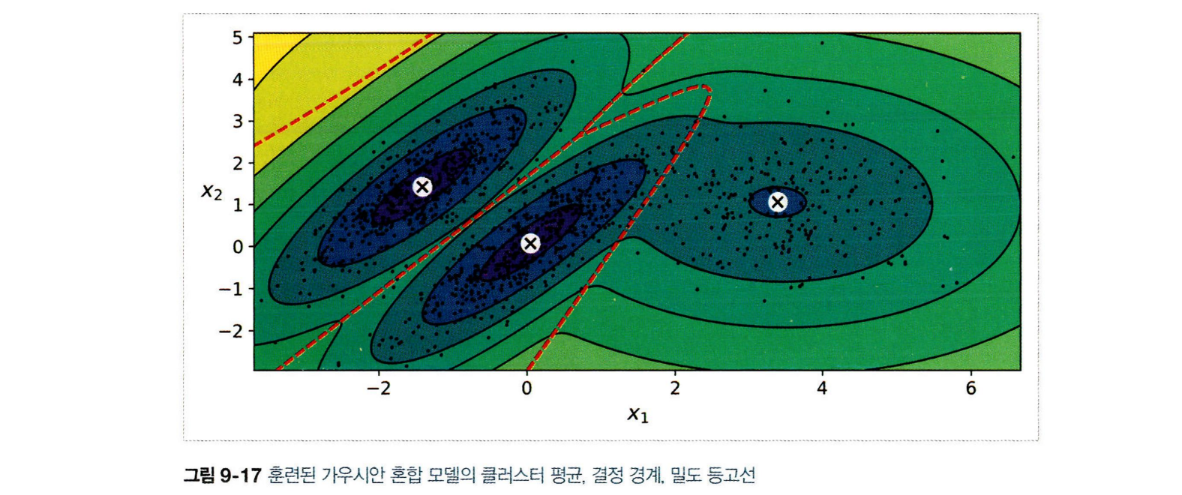

**EM이 최적의 솔루션으로 수렴하기 어려운 경우**
- 특성, 클러스터가 많거나 샘플 수가 적은 경우
- 알고리즘이 학습할 파라미터의 개수를 제한해야 함
- 클러스터의 모양, 방향의 범위 제한 등

> covariance_type 매개변수에 아래 값 중 하나 설정
- 디폴트는 "full"

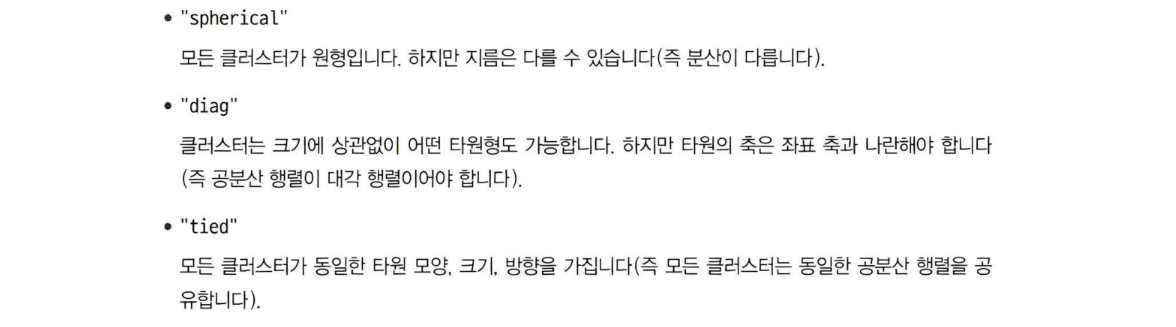

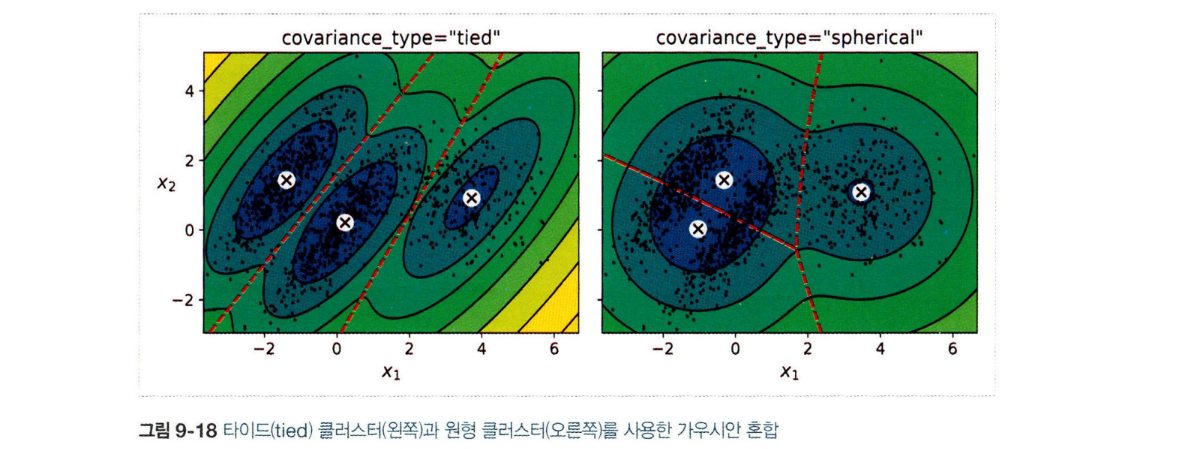

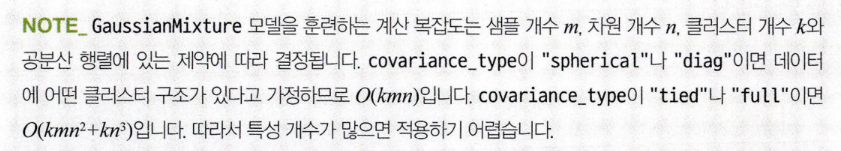

## 9.2.1 가우시안 혼합을 사용한 이상치 탐지

**이상치 탐지**
- 보통과 많이 다른 샘플을 감지하는 작업

**가우시안 모델에서 이상치를 탐지하는 방법**
- 밀도가 낮은 지역에 있는 모든 값을 이상치로 처리
 - 밀도 임곗값을 정해야 함
    - 거짓 양성(정상이 결함으로 처리)이 많으면 임곗값 낮춤
    - 거짓 음성(결함이 정상으로 처리)이 많으면 임곗값 높임

In [31]:
# 밀도 임곗값을 4%로 해서 이상치 구분
import numpy as np

densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)
anomalies = X[densities < density_threshold]

**특이치 탐지**
- 이상치로 오염되지 않은 데이터셋에서 훈련함

## 9.2.2 클러스터 개수 선택하기

**가우시안 혼합에서 클러스터 수 선택하기**
- k-평균에서는 이너셔, 실루엣 점수 등 사용
- 이는 클러스터가 타원형이거나 크기가 다를 때 안정적이지 못하므로, 사용 불가
- **이론적 정보 기준**을 최소화하는 방법 사용!
 - BIC
 - AIC
 - 학습할 파라미터가 많은 모델에게 벌칙을 가하고, 데이터에 잘 학습했을 경우 보상을 줌
 - 같은 모델을 선택하거나, 다를 경우 BIC가 더 간단

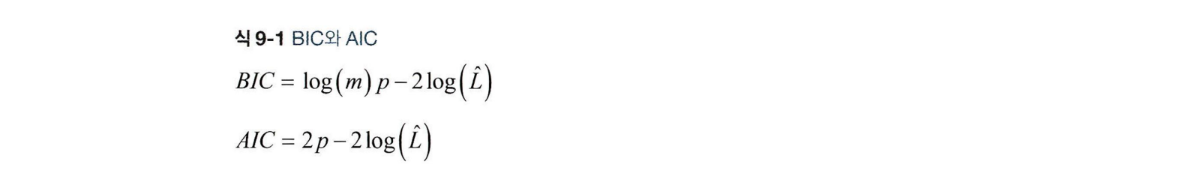

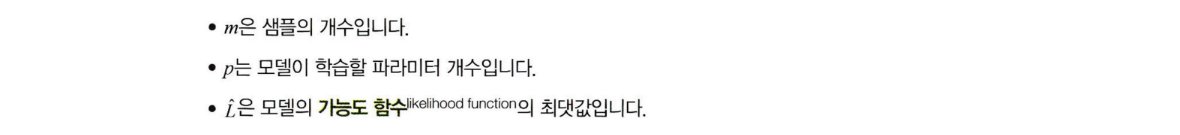

In [32]:
# BIC 계산 - bic() 메서드

gm.bic(X)

np.float64(2788.177255355537)

In [33]:
# AIC 계산 - aic() 메서드

gm.aic(X)

np.float64(2704.7454156128406)

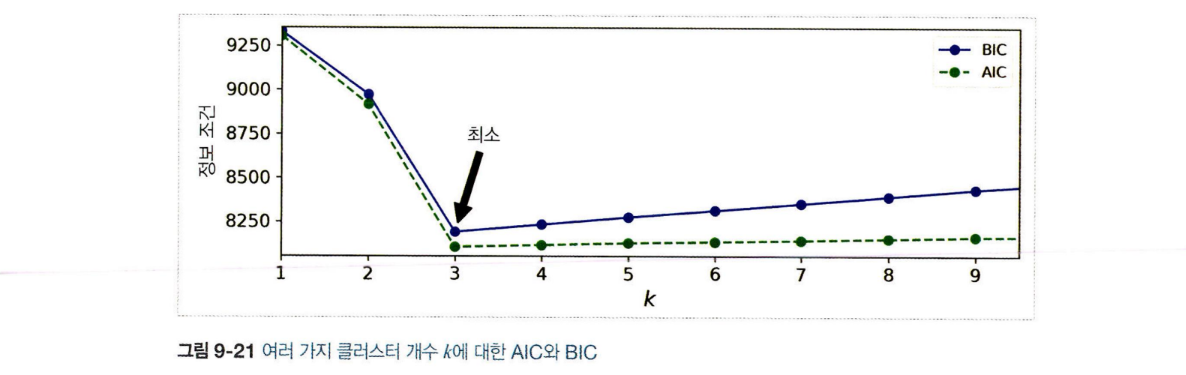

    - k=3 에서 BIC와 AIC가 모두 가장 작음

- covariance_type 매개변수를 "full" 대신 "spherical"을 선택하면, 학습할 파라미터 크게 감소 but 데이터에 잘 맞지X

## 9.2.3 베이즈 가우시안 혼합 모델

**BayesianGaussianMixture**
- 최적의 클러스터 수를 찾지 않고, 불필요한 클러스터의 가중치를 0으로 만듦
- 클러스터 파라미터(가중치, 평균, 공분산 행렬)는 잠재 확률 변수로 취급 -> z는 클러스터 파라미터와 클러스터 할당을 모두 포함함.

In [34]:
# 클러스터 개수 n_components를 최적의 클러스터 수보다 크다고 믿을만하게 지정
# 10으로 지정

from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=10)
bgm.fit(X)
np.round(bgm.weights_, 2)

/usr/local/lib/python3.11/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.15, 0.14, 0.11, 0.  , 0.09, 0.14, 0.12, 0.14, 0.11, 0.  ])

- 6개의 클러스터 감지

**베타 분포**
- 고정 범위 안에 놓인 값을 가진 확률 변수를 모델링할 때 자주 사용
 - 0에서 1 범위

- SBP
 - $\Phi$ = [0.3, 0.6, 0.5, ...] 를 가정하면 샘플의 30%가 0에, 남은 샘플의 60%가 1에, 남은 샘플의 50%가 2에 할당되는 식
 - 농도 $a$
    - 크면 $\Phi$값이 0에 가까워지고 클러스터 많아짐
    - 낮으면 $\Phi$값이 1에 가까워지고 클러스터 적음
- 위샤트 분포
 - 공분산 행렬을 샘플링함
 - 파라미터 d와 V가 클러스터 분포 모양을 제어함

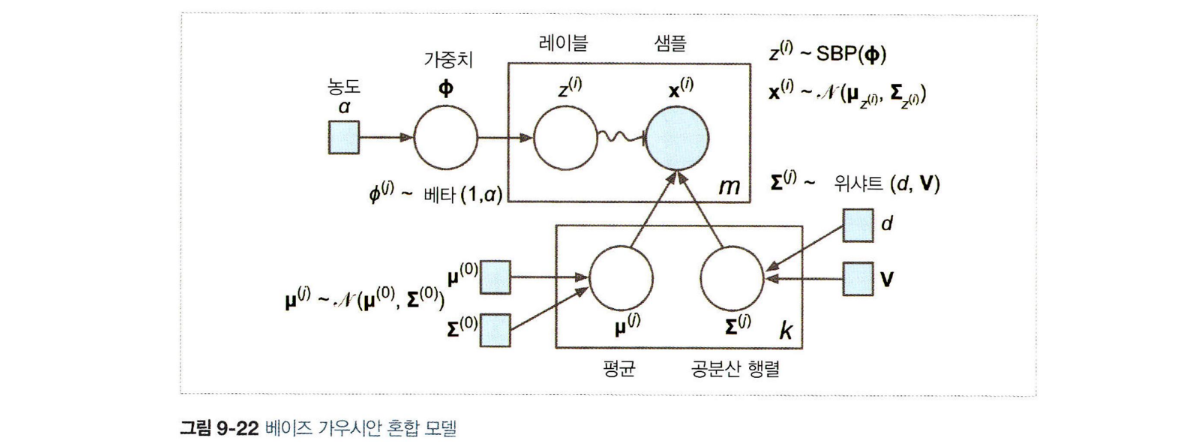

**weight_concentration_prior 매개변수**
- 잠재 변수 z에 대한 사전 확률을 p(z)에 인코딩 가능
- 사전 믿음
 - 농도 낮음(클러스터 적음)
 - 농도 높음(클러스터 많음)

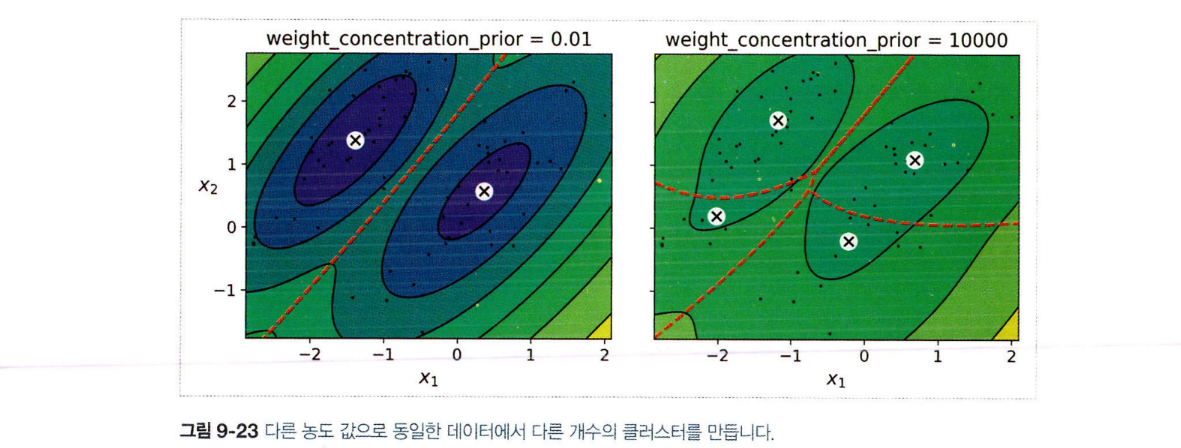

> **베이즈 정리**

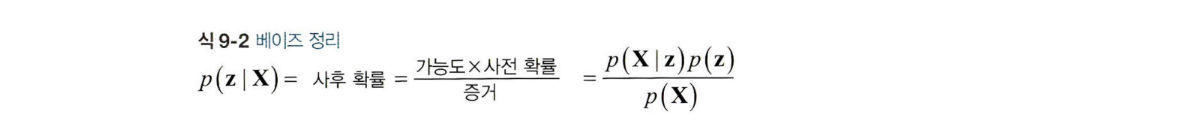

**한계**
- p(X)는 구하기 어렵다
- 가능한 모든 z값에 대해 적분해야 하기 때문

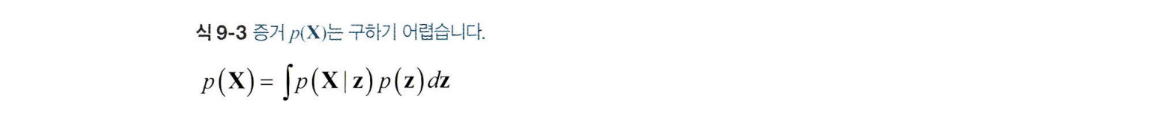

**해결법-변분 추론**
- 변분 파라미터 람다를 가진 분포 패밀리 $q(z; \lambda)$를 선택
- $q(z)$가 $p(z \mid \mathbf{X})$
의 좋은 근삿값이 되도록 람다를 최적화
 - $q(z)$에서 $p(z \mid \mathbf{X})$ 로의 KL 발산을 최소화
 - log $p({X})$ - ELBO
     - 즉, ELBO를 최대화하는 람다 찾기

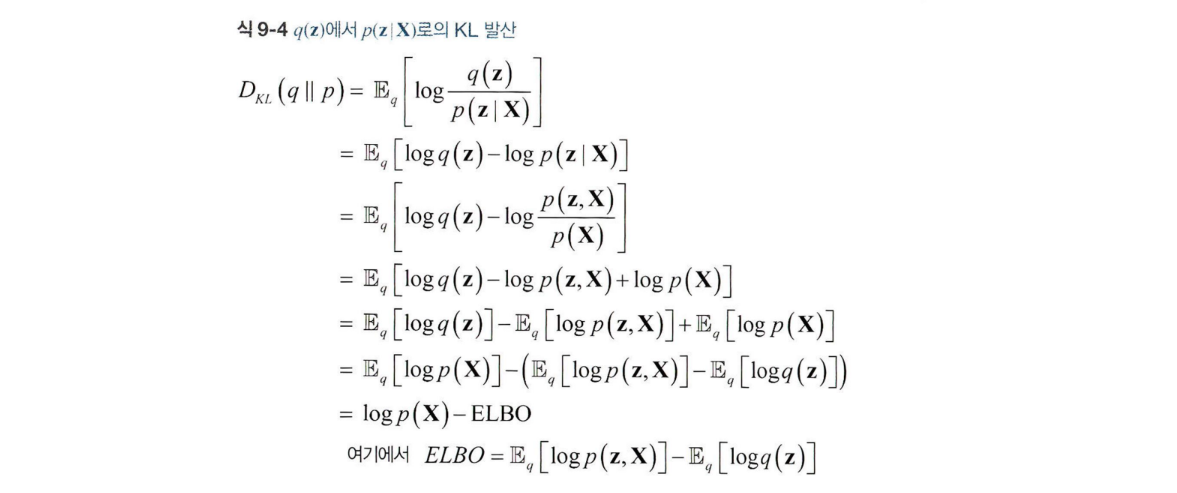

**블랙 박스 확률적 변분 추론**
- ELBO를 최대화하는 간단한 방법
- 각 반복에서 샘플을 q에서 뽑아 람다에 대한 ELBO의 기울기 추정에 사용
- 그리고 경사 상승법 스텝에 사용

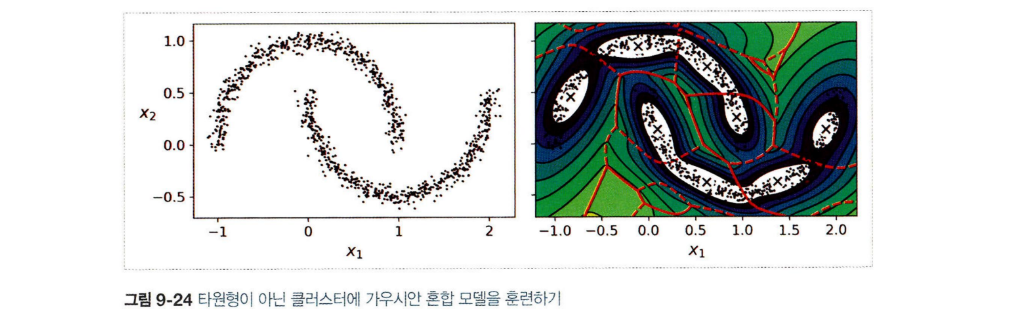

    - 베이지안 혼합 모델은 위와 같이 필사적으로 타원형을 찾음
    - 2개가 아닌 8개의 클러스터로 구분함

## 9.2.4 이상치 탐지와 특이치 탐지를 위한 다른 알고리즘

**이상치와 특이치를 감지하는 사이킷런의 알고리즘**
- PCA
- Fast-MCD
- 아이솔레이션 포레스트
- LOF
- one-class SVM